# Sentiment Analysis Experiment

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Create output directory for saving plots
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

print("=" * 55)
print("       SENTIMENT ANALYSIS EXPERIMENT")
print("=" * 55)

Output directory: /content/outputs
       SENTIMENT ANALYSIS EXPERIMENT


In [4]:
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
print("✅ NLTK resources ready.")

✅ NLTK resources ready.


In [5]:
# 50 sample reviews (25 positive + 25 negative)
reviews = [
    ("This movie was absolutely fantastic! Great acting and brilliant story.", 1),
    ("One of the best films I have ever seen. A true masterpiece.", 1),
    ("Amazing cinematography and deeply moving performances throughout.", 1),
    ("I loved every minute of it. Brilliant direction by the filmmaker.", 1),
    ("Wonderful film, touching and beautifully crafted from start to finish.", 1),
    ("Superb acting, gripping plot, highly recommended for everyone.", 1),
    ("A perfect blend of drama and humor. Absolutely loved it!", 1),
    ("Outstanding performance by the lead actor. A must watch film.", 1),
    ("The storyline was engaging and kept me hooked till the end.", 1),
    ("Heartwarming and inspirational. A true gem of modern cinema.", 1),
    ("Absolutely brilliant! One of the best movies of the decade.", 1),
    ("The characters felt real and relatable. An excellent movie.", 1),
    ("A visually stunning and emotionally powerful cinematic experience.", 1),
    ("The script was sharp and the pacing was absolutely perfect.", 1),
    ("Delightful, funny, and deeply human. Loved everything about it.", 1),
    ("Incredible film with amazing special effects and great story.", 1),
    ("The director did a fantastic job bringing this story to life.", 1),
    ("Every scene was crafted with care and attention to detail.", 1),
    ("A truly unforgettable experience. Will watch again for sure.", 1),
    ("Phenomenal movie. The best thing I have watched this year.", 1),
    ("Great music, great cast, great story. Everything was perfect.", 1),
    ("This film moved me to tears. Beautifully written and directed.", 1),
    ("Jaw dropping visuals and an emotionally gripping storyline.", 1),
    ("A cinematic triumph. Powerful, moving, and incredibly well made.", 1),
    ("Loved the characters and the plot. Highly recommend this film.", 1),
    ("Terrible movie. Complete waste of time and money.", 0),
    ("Awful storyline with no direction whatsoever. Very boring.", 0),
    ("I hated every second of it. Poor acting and a bad script.", 0),
    ("Boring and predictable. Absolutely nothing special at all.", 0),
    ("Disappointing film with very poor execution and weak story.", 0),
    ("The worst movie I have seen in years. Please avoid it.", 0),
    ("Dreadful plot, wooden acting, and horrible dialogue throughout.", 0),
    ("A complete disaster from beginning to end. Zero stars.", 0),
    ("Painfully slow and utterly confusing storyline. Not worth it.", 0),
    ("No redeeming qualities at all. A total waste of everyone's time.", 0),
    ("Laughably bad. The script made absolutely no sense at all.", 0),
    ("Flat characters and a very predictable and boring plot.", 0),
    ("I walked out halfway through the film. That bad.", 0),
    ("Terrible direction and very poor production quality overall.", 0),
    ("An embarrassment to cinema. Could not watch till the end.", 0),
    ("Utterly unwatchable. The acting was painfully bad throughout.", 0),
    ("Nothing worked in this film. Bad story, bad acting, bad direction.", 0),
    ("I regret watching this. Two hours of my life completely wasted.", 0),
    ("The plot made no sense and the ending was deeply unsatisfying.", 0),
    ("Boring from the very first scene. I almost fell asleep watching.", 0),
    ("Poorly written characters with zero depth or development.", 0),
    ("The worst script I have ever encountered in a mainstream film.", 0),
    ("Absolutely no entertainment value. A forgettable mess of a film.", 0),
    ("Save your money and your time. This film is not worth either.", 0),
    ("One of the most unpleasant viewing experiences I have ever had.", 0),
]

df = pd.DataFrame(reviews, columns=["text", "label"])
print(f"\n📊 Total Reviews  : {len(df)}")
print(f"✅ Positive (1)   : {(df.label == 1).sum()}")
print(f"❌ Negative (0)   : {(df.label == 0).sum()}")


📊 Total Reviews  : 50
✅ Positive (1)   : 25
❌ Negative (0)   : 25


In [6]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text   = text.lower()                          # lowercase
    text   = re.sub(r"[^a-z\s]", " ", text)       # remove punctuation/numbers
    words  = text.split()                          # split into words
    words  = [w for w in words if w not in stop_words and len(w) > 2]  # remove stopwords
    return " ".join(words)

df["cleaned"] = df["text"].apply(clean_text)
print("\n✅ Text preprocessing done.")
print(f"   Original : {df['text'][0]}")
print(f"   Cleaned  : {df['cleaned'][0]}")


✅ Text preprocessing done.
   Original : This movie was absolutely fantastic! Great acting and brilliant story.
   Cleaned  : movie absolutely fantastic great acting brilliant story


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    df["cleaned"], df["label"], test_size=0.2, random_state=42
)
print(f"✂️  Train: {len(X_train)} | Test: {len(X_test)}")

✂️  Train: 40 | Test: 10


In [8]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"✅ TF-IDF features: {X_train_tfidf.shape[1]}")

✅ TF-IDF features: 363


In [9]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Naive Bayes"         : MultinomialNB(),
    "Linear SVM"          : LinearSVC(max_iter=2000),
}

results = {}
print("\n" + "=" * 55)
print("           MODEL RESULTS")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred   = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {"model": model, "y_pred": y_pred, "accuracy": accuracy}
    print(f"\n🔹 {name}")
    print(f"   Accuracy : {accuracy * 100:.1f}%")
    print(classification_report(y_test, y_pred,
                                target_names=["Negative", "Positive"],
                                zero_division=0))


           MODEL RESULTS

🔹 Logistic Regression
   Accuracy : 30.0%
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         7
    Positive       0.30      1.00      0.46         3

    accuracy                           0.30        10
   macro avg       0.15      0.50      0.23        10
weighted avg       0.09      0.30      0.14        10


🔹 Naive Bayes
   Accuracy : 60.0%
              precision    recall  f1-score   support

    Negative       1.00      0.43      0.60         7
    Positive       0.43      1.00      0.60         3

    accuracy                           0.60        10
   macro avg       0.71      0.71      0.60        10
weighted avg       0.83      0.60      0.60        10


🔹 Linear SVM
   Accuracy : 50.0%
              precision    recall  f1-score   support

    Negative       0.75      0.43      0.55         7
    Positive       0.33      0.67      0.44         3

    accuracy                           0.50 

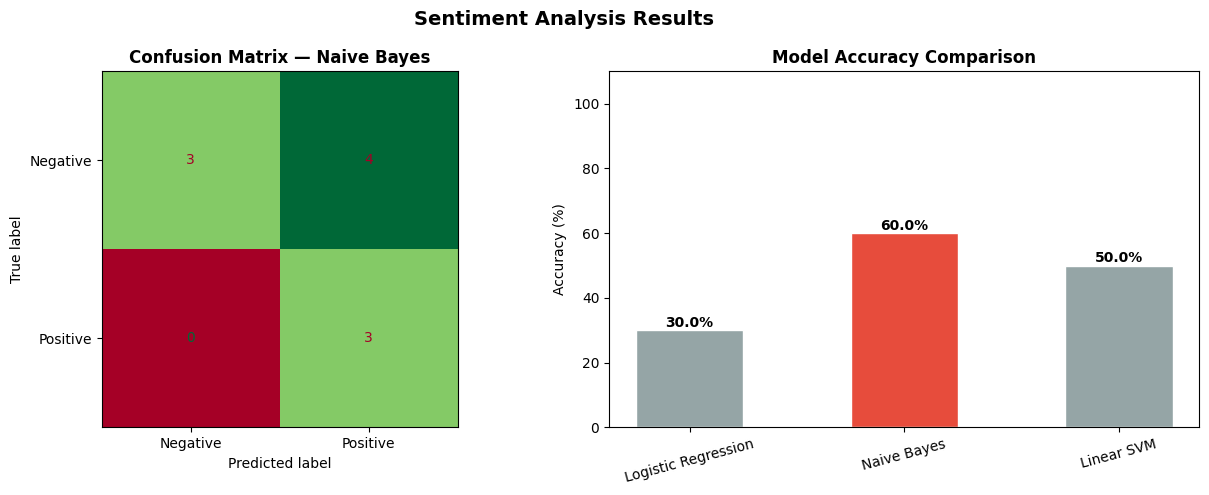

✅ Plot saved.


In [10]:
best_name  = max(results, key=lambda k: results[k]["accuracy"])
best_pred  = results[best_name]["y_pred"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Sentiment Analysis Results", fontsize=14, fontweight="bold")

# Confusion Matrix
ax = axes[0]
cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(
    ax=ax, colorbar=False, cmap="RdYlGn"
)
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")

# Model Accuracy Comparison
ax = axes[1]
names  = list(results.keys())
accs   = [results[m]["accuracy"] * 100 for m in names]
colors = ["#e74c3c" if m == best_name else "#95a5a6" for m in names]
bars   = ax.bar(names, accs, color=colors, edgecolor="white", width=0.5)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
ax.set_title("Model Accuracy Comparison", fontweight="bold")
ax.tick_params(axis="x", rotation=15)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sentiment_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Plot saved.")

In [11]:
print("\n" + "=" * 55)
print("         TRY YOUR OWN REVIEW")
print("=" * 55)

best_model = results[best_name]["model"]

def predict(review):
    cleaned  = clean_text(review)
    features = tfidf.transform([cleaned])
    pred     = best_model.predict(features)[0]
    result   = "✅ POSITIVE 😊" if pred == 1 else "❌ NEGATIVE 😞"
    print(f"\n📝 {review[:70]}")
    print(f"   → {result}")

predict("This was an absolutely amazing film! Loved every second of it.")
predict("Terrible movie. Boring, bad acting, complete waste of time.")
predict("The movie was okay, not great but not bad either.")

print(f"\n🏆 Best Model :", best_name)
print("✅ Experiment complete!")


         TRY YOUR OWN REVIEW

📝 This was an absolutely amazing film! Loved every second of it.
   → ✅ POSITIVE 😊

📝 Terrible movie. Boring, bad acting, complete waste of time.
   → ❌ NEGATIVE 😞

📝 The movie was okay, not great but not bad either.
   → ✅ POSITIVE 😊

🏆 Best Model : Naive Bayes
✅ Experiment complete!
